# Analyse exploratoire des données souvent appelée EDA (Exploratory Data Analysis) du jeu de données CIFAR-100

Ce notebook:

- présente le type de données : dimensions, formats, variables, labels, contraintes ;
- montre la donnée brute quand c'est pertinent ;
- analyse les distributions en disant quelque chose de solide sur les histogrammes ;
- synthétise l'information quand le nombre de variables est grand ;
- utilise des visualisations linéaires et non linéaires avec recul critique ;
- réponds explicitement à la question de la séparabilité en 2, 3, puis davantage de dimensions.


In [1]:
import pickle
# Permet de sérialiser et désérialiser des objets Python
import tarfile
# Sert à lire et créer des archives .tar
import urllib.request
# Permet de télécharger des ressources depuis une URL
import warnings
# Gère l’affichage et le filtrage des avertissements
from pathlib import Path
# Fournit une manière moderne de manipuler les chemins de fichiers

import numpy as np
# Bibliothèque pour le calcul numérique et les tableaux multidimensionnels
import pandas as pd
# Bibliothèque pour la manipulation et l’analyse de données tabulaires
import matplotlib.pyplot as plt
# Module de traçage de graphiques avec Matplotlib

from scipy import stats
# Contient des fonctions statistiques

from sklearn.decomposition import PCA
# Outil de réduction de dimension par analyse en composantes principales
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
# Méthode supervisée de réduction de dimension / classification
from sklearn.linear_model import RidgeClassifier
# Classificateur linéaire avec régularisation Ridge
from sklearn.manifold import TSNE
# t-SNE pour projection non linéaire
from sklearn.metrics import accuracy_score
# Métriques d’évaluation pour classification et clustering
from sklearn.model_selection import train_test_split
# Sert à découper les données en ensembles d’entraînement et de test
from sklearn.preprocessing import StandardScaler
# Standardise les données en supprimant la moyenne et en divisant par l’écart-type

warnings.filterwarnings("ignore")
# Ignore tous les avertissements affichés pendant l’exécution
plt.rcParams["figure.figsize"] = (10, 6)
# Définit la taille par défaut des figures matplotlib
plt.rcParams["axes.grid"] = True
# Active la grille sur les axes des graphiques par défaut

DATA_DIR = Path("./data")
# Définit le chemin du dossier de stockage des données
DATA_DIR.mkdir(parents=True, exist_ok=True)
# Crée le dossier s’il n’existe pas, ainsi que ses éventuels parents

RANDOM_STATE = 42
# Fixe une graine aléatoire pour garantir la reproductibilité
EDA_SAMPLE_SIZE = 4000
# Taille de l’échantillon utilisé pour l’analyse exploratoire et la PCA
NONLINEAR_SAMPLE_SIZE = 2500
# Taille du sous-échantillon utilisé pour t-SNE / UMAP
PIXEL_SAMPLE_SIZE = 150_000
# Nombre de pixels échantillonnés pour certaines analyses
PCA_MAX_COMPONENTS = 256
# Nombre maximal de composantes principales à conserver

rng = np.random.default_rng(RANDOM_STATE)
# Crée un générateur aléatoire NumPy reproductible

print("Répertoire de travail :", DATA_DIR.resolve())
# Affiche le chemin absolu du dossier de travail

Répertoire de travail : /home/defaultuser/Téléchargements/data


## 1. Chargement des données brutes

On charge ici la version officielle CIFAR-100:
- 50 000 images d'entraînement ;
- 10 000 images de test ;
- images couleur 32 × 32 × 3 ;
- 100 classes fines et 20 super-classes.


In [2]:
CIFAR100_URL = "https://www.cs.toronto.edu/~kriz/cifar-100-python.tar.gz"  
# URL du fichier compressé du jeu de données CIFAR-100
archive_path = DATA_DIR / "cifar-100-python.tar.gz"  
# Chemin local où l’archive téléchargée sera enregistrée
raw_dir = DATA_DIR / "cifar-100-python"  
# Dossier local contenant les données extraites

def ensure_cifar100_downloaded():  
    # Définit une fonction qui vérifie, télécharge et extrait CIFAR-100 si nécessaire
    if raw_dir.exists():  
        # Vérifie si le dossier des données extraites existe déjà
        print("Données déjà présentes :", raw_dir.resolve())  
        # Affiche le chemin absolu si les données sont déjà disponibles
        return  
        # Quitte la fonction pour éviter un nouveau téléchargement ou une nouvelle extraction
    if not archive_path.exists():  
        # Vérifie si l’archive compressée n’a pas encore été téléchargée
        print("Téléchargement de CIFAR-100...")  
        # Informe l’utilisateur que le téléchargement commence
        urllib.request.urlretrieve(CIFAR100_URL, archive_path)  
        # Télécharge l’archive CIFAR-100 depuis l’URL vers le chemin local
    print("Extraction de l'archive...")  
    # Informe l’utilisateur que l’extraction commence
    with tarfile.open(archive_path, "r:gz") as tar:  
        # Ouvre l’archive .tar.gz en lecture
        tar.extractall(DATA_DIR)  
        # Extrait tout le contenu de l’archive dans le dossier DATA_DIR

def load_pickle(path):  
    # Définit une fonction pour charger un fichier pickle
    with open(path, "rb") as f:  
        # Ouvre le fichier en mode lecture binaire
        return pickle.load(f, encoding="latin1")  
        # Charge et retourne le contenu du pickle avec l’encodage latin1

ensure_cifar100_downloaded()  
# Appelle la fonction pour s’assurer que CIFAR-100 est bien téléchargé et extrait

meta = load_pickle(raw_dir / "meta")  
# Charge le fichier de métadonnées contenant les noms des classes
train_raw = load_pickle(raw_dir / "train")  
# Charge les données brutes de l’ensemble d’entraînement
test_raw = load_pickle(raw_dir / "test")  
# Charge les données brutes de l’ensemble de test

fine_label_names = [x.decode("utf-8") if isinstance(x, bytes) else x for x in meta["fine_label_names"]]  
# Convertit les noms des classes fines en chaînes UTF-8 si nécessaire
coarse_label_names = [x.decode("utf-8") if isinstance(x, bytes) else x for x in meta["coarse_label_names"]]  
# Convertit les noms des super-classes en chaînes UTF-8 si nécessaire

X_train = train_raw["data"].reshape(-1, 3, 32, 32).transpose(0, 2, 3, 1)  
# Reformate les images d’entraînement en tableau (N, 32, 32, 3)
X_test = test_raw["data"].reshape(-1, 3, 32, 32).transpose(0, 2, 3, 1)  
# Reformate les images de test en tableau (N, 32, 32, 3)

y_train = np.array(train_raw["fine_labels"])  
# Convertit les labels fins d’entraînement en tableau NumPy
y_test = np.array(test_raw["fine_labels"])  
# Convertit les labels fins de test en tableau NumPy
y_train_coarse = np.array(train_raw["coarse_labels"])  
# Convertit les super-labels d’entraînement en tableau NumPy
y_test_coarse = np.array(test_raw["coarse_labels"])  
# Convertit les super-labels de test en tableau NumPy

X_train_f = X_train.astype(np.float32) / 255.0  
# Convertit les pixels d’entraînement en float32 et les normalise entre 0 et 1
X_test_f = X_test.astype(np.float32) / 255.0  
# Convertit les pixels de test en float32 et les normalise entre 0 et 1

print("Train shape :", X_train.shape, "| dtype :", X_train.dtype)  
# Affiche la forme et le type des données d’entraînement
print("Test shape  :", X_test.shape, "| dtype :", X_test.dtype)  
# Affiche la forme et le type des données de test
print("Nb classes fines :", len(fine_label_names))  
# Affiche le nombre de classes fines
print("Nb super-classes :", len(coarse_label_names))  
# Affiche le nombre de super-classes

Données déjà présentes : /home/defaultuser/Téléchargements/data/cifar-100-python
Train shape : (50000, 32, 32, 3) | dtype : uint8
Test shape  : (10000, 32, 32, 3) | dtype : uint8
Nb classes fines : 100
Nb super-classes : 20


## 2. Nature des données, dimensions, formats et variables

Avant toute visualisation, il faut expliciter **ce qui est observé** :

- l'**entrée brute** est une image RGB ;
- la **représentation analytique** classique est un vecteur de **3072 pixels** ;
- la **cible principale** est la classe fine ;
- la **cible agrégée** est la super-classe.

Cette distinction est importante : une partie des visualisations est lisible au niveau des **20 super-classes**, alors que la séparation des **100 classes fines** est beaucoup plus difficile.


In [3]:

schema_df = pd.DataFrame([
    # Crée un DataFrame pandas à partir d’une liste de dictionnaires décrivant les variables du jeu de données
    {
        "variable": "image",
        "rôle": "entrée",
        "type": "numérique",
        "format": "tableau 32×32×3",
        "dtype": str(X_train.dtype),
        "nb_variables_effectif": 32 * 32 * 3,
        "commentaire": "pixels RGB codés entre 0 et 255"
    },
    {
        "variable": "image_float",
        "rôle": "entrée normalisée",
        "type": "numérique",
        "format": "tableau 32×32×3",
        "dtype": "float32",
        "nb_variables_effectif": 32 * 32 * 3,
        "commentaire": "pixels ramenés entre 0 et 1"
    },
    {
        "variable": "image_flat",
        "rôle": "représentation analytique",
        "type": "numérique",
        "format": "vecteur 3072",
        "dtype": "float32 / float64",
        "nb_variables_effectif": 3072,
        "commentaire": "utile pour PCA, LDA, t-SNE, UMAP"
    },
    {
        "variable": "fine_label",
        "rôle": "cible principale",
        "type": "catégorielle",
        "format": "scalaire entier",
        "dtype": str(y_train.dtype),
        "nb_variables_effectif": 1,
        "commentaire": "100 classes fines"
    },
    {
        "variable": "coarse_label",
        "rôle": "cible agrégée",
        "type": "catégorielle",
        "format": "scalaire entier",
        "dtype": str(y_train_coarse.dtype),
        "nb_variables_effectif": 1,
        "commentaire": "20 super-classes"
    },
])

display(schema_df)  
# Affiche le DataFrame dans un notebook ou un environnement interactif

print("NaN train :", np.isnan(X_train).sum())  
# Affiche le nombre total de valeurs manquantes dans les données d’entraînement
print("NaN test  :", np.isnan(X_test).sum())  
# Affiche le nombre total de valeurs manquantes dans les données de test
print("Pixels min/max train :", X_train.min(), X_train.max())  
# Affiche les valeurs minimale et maximale des pixels du jeu d’entraînement


,variable,rôle,type,format,dtype,nb_variables_effectif,commentaire
0,image,entrée,numérique,tableau 32×32×3,uint8,3072,pixels RGB codés entre 0 et 255
1,image_float,entrée normalisée,numérique,tableau 32×32×3,float32,3072,pixels ramenés entre 0 et 1
2,image_flat,représentation analytique,numérique,vecteur 3072,float32 / float64,3072,"utile pour PCA, LDA, t-SNE, UMAP"
3,fine_label,cible principale,catégorielle,scalaire entier,int64,1,100 classes fines
4,coarse_label,cible agrégée,catégorielle,scalaire entier,int64,1,20 super-classes


NaN train : 0
NaN test  : 0
Pixels min/max train : 0 255


### Lecture

Le dataset est propre et dense :
- pas de valeurs manquantes ;
- pixels entiers entre 0 et 255 ;
- structure très régulière, ce qui facilite les manipulations ;
- en revanche, les 3072 variables de pixels sont très nombreuses et très corrélées spatialement, ce qui justifie ensuite l'usage de descripteurs synthétiques et de réductions de dimension.


## 3. Représentation brute de la donnée

Comme il s'agit d'images, il est pertinent de montrer la donnée brute.  
On affiche :
1. un échantillon aléatoire d'images ;
2. une image représentative par super-classe pour visualiser la diversité sémantique.


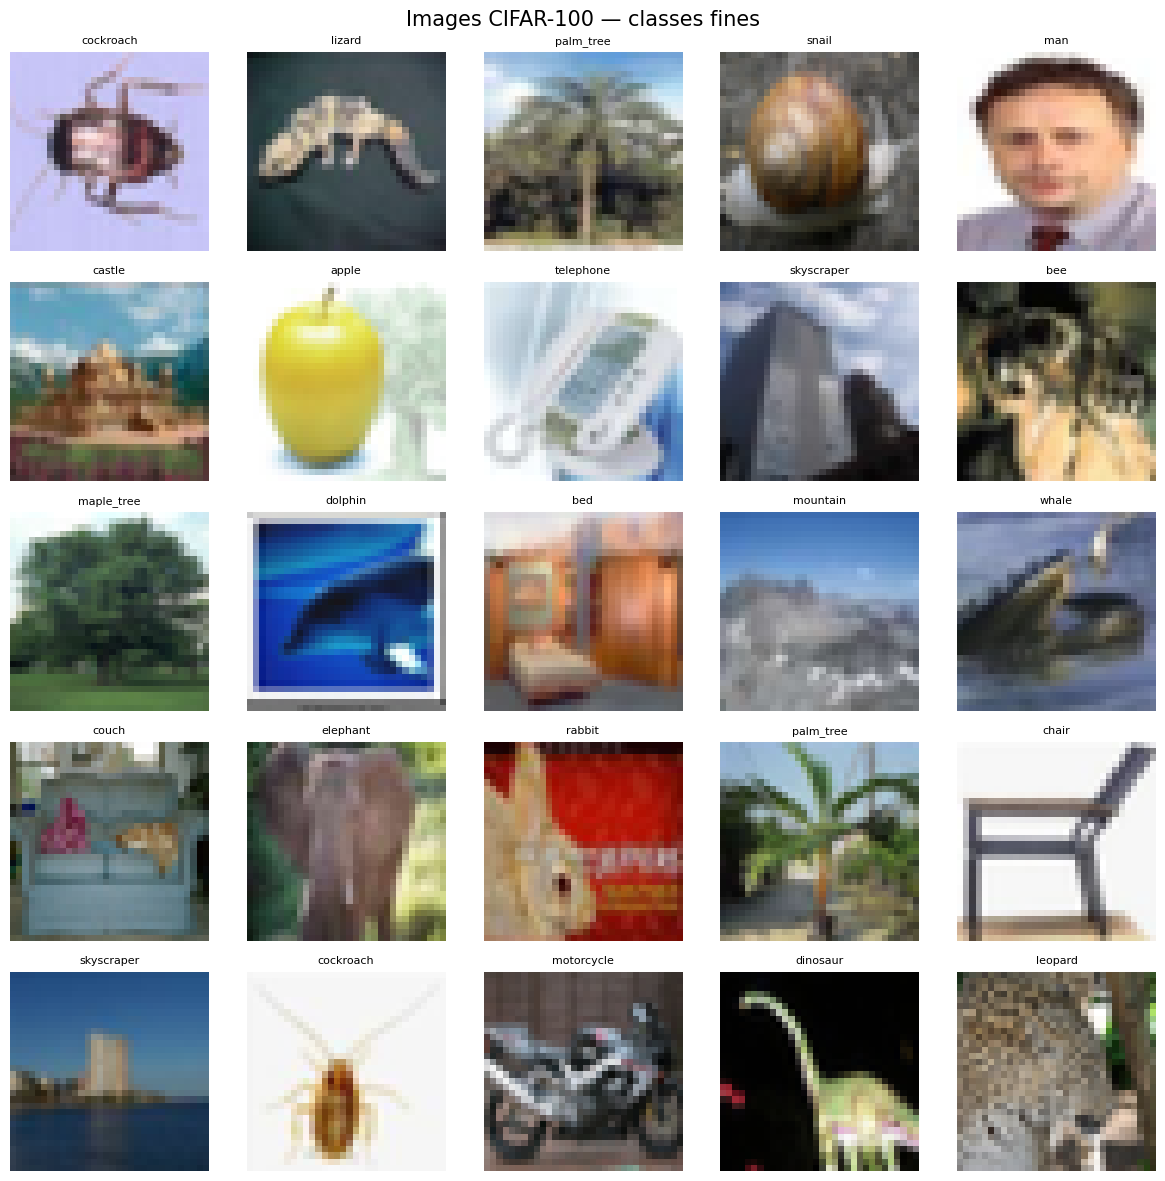

In [4]:
def show_samples(images, labels, names, n=25, title="Échantillon aléatoire"):  
    # Définit une fonction pour afficher un ensemble d’images choisies aléatoirement avec leurs labels
    idx = rng.choice(len(images), size=n, replace=False)  
    # Tire aléatoirement n indices différents parmi toutes les images
    side = int(np.ceil(np.sqrt(n)))  
    # Calcule le nombre de lignes/colonnes nécessaires pour disposer les images en grille carrée
    fig, axes = plt.subplots(side, side, figsize=(12, 12))  
    # Crée une figure matplotlib avec une grille de sous-graphiques
    axes = axes.ravel()  
    # Aplati le tableau 2D des axes en vecteur 1D pour faciliter la boucle
    for ax in axes:  
        # Parcourt tous les sous-graphiques
        ax.axis("off")  
        # Masque les axes pour ne pas afficher les graduations autour des images
    for ax, i in zip(axes, idx):  
        # Associe chaque axe disponible à un indice d’image sélectionné
        ax.imshow(images[i])  
        # Affiche l’image correspondant à l’indice i
        ax.set_title(names[int(labels[i])], fontsize=8)  
        # Affiche comme titre le nom de la classe de l’image
        ax.axis("off")  
        # Masque de nouveau les axes du sous-graphe
    plt.suptitle(title, fontsize=15)  
    # Ajoute un titre global à la figure
    plt.tight_layout()  
    # Ajuste automatiquement les espacements pour éviter les chevauchements
    plt.show()  
    # Affiche la figure à l’écran

show_samples(X_train, y_train, fine_label_names, n=25, title="Images CIFAR-100 — classes fines")  
# Appelle la fonction pour afficher 25 images aléatoires du jeu d’entraînement avec leurs classes fines

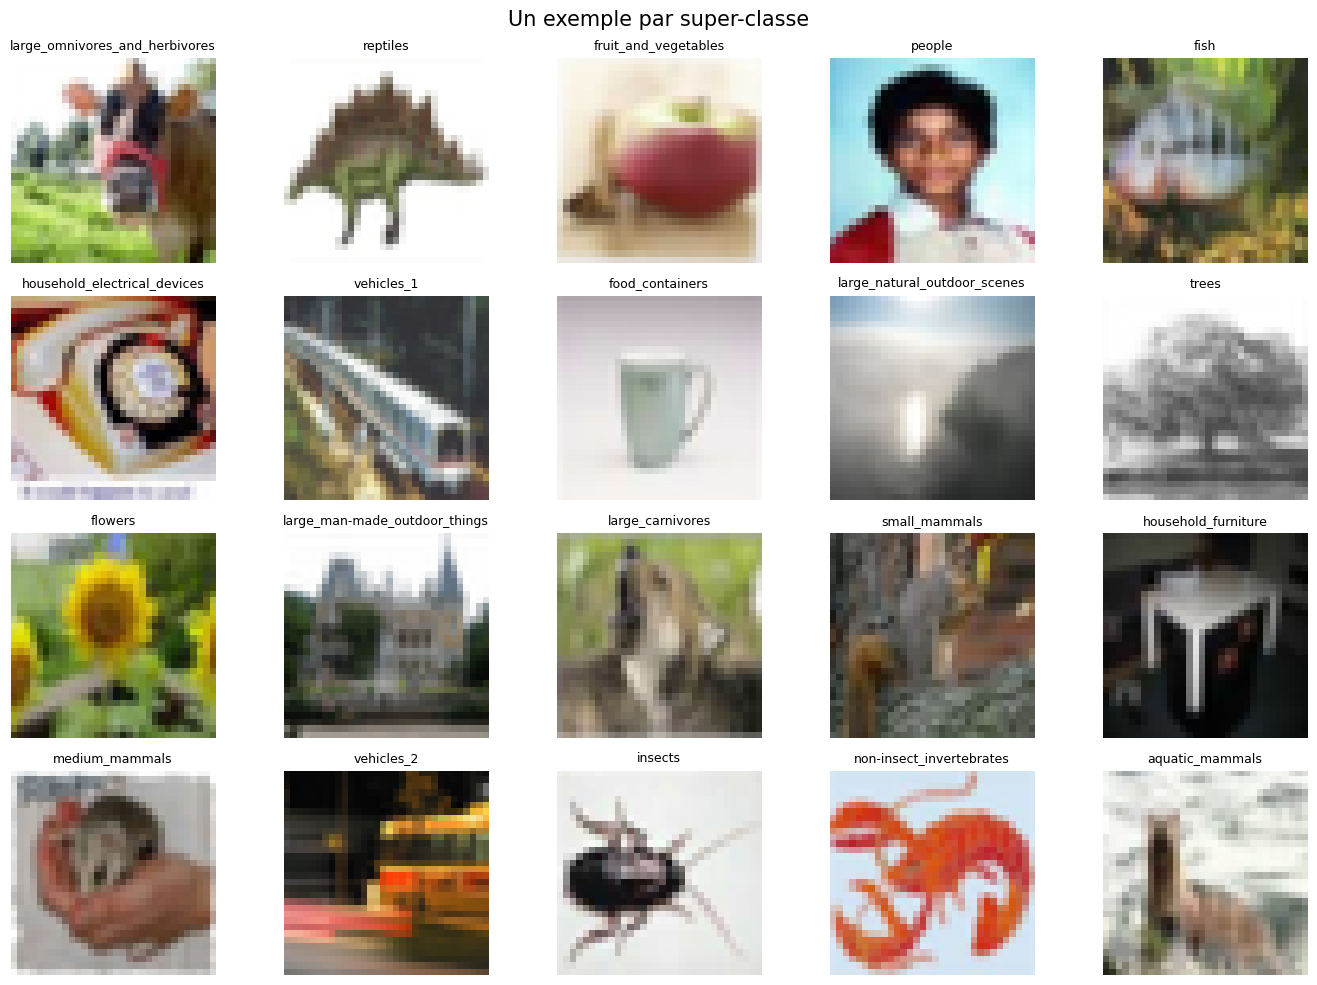

In [5]:
selected_idx = []  
# Initialise une liste vide qui contiendra les indices sélectionnés
seen = set()  
# Initialise un ensemble vide pour mémoriser les super-classes déjà rencontrées

for i, coarse in enumerate(y_train_coarse):  
    # Parcourt les labels de super-classes du jeu d’entraînement avec leur indice
    if coarse not in seen:  
        # Vérifie si cette super-classe n’a pas encore été rencontrée
        selected_idx.append(i)  
        # Ajoute l’indice de cette image à la liste des indices sélectionnés
        seen.add(int(coarse))  
        # Ajoute cette super-classe à l’ensemble des classes déjà vues
    if len(selected_idx) == len(coarse_label_names):  
        # Vérifie si on a déjà trouvé un exemple pour chaque super-classe
        break  
        # Arrête la boucle dès que toutes les super-classes sont représentées

fig, axes = plt.subplots(4, 5, figsize=(14, 10))  
# Crée une figure avec une grille de 4 lignes et 5 colonnes pour afficher 20 images
for ax, idx in zip(axes.ravel(), selected_idx):  
    # Associe chaque sous-graphe à un indice sélectionné
    ax.imshow(X_train[idx])  
    # Affiche l’image d’entraînement correspondant à cet indice
    ax.set_title(coarse_label_names[y_train_coarse[idx]], fontsize=9)  
    # Affiche en titre le nom de la super-classe de l’image
    ax.axis("off")  
    # Masque les axes pour une meilleure lisibilité de l’image
plt.suptitle("Un exemple par super-classe", fontsize=15)  
# Ajoute un titre global à la figure
plt.tight_layout()  
# Ajuste automatiquement les espacements entre les sous-graphes
plt.show()  
# Affiche la figure

### Lecture

La représentation brute montre immédiatement trois propriétés importantes :

- les classes sont visuellement riches et hétérogènes ;
- les objets apparaissent dans des contextes variés, avec fond, texture, éclairage et cadrage changeants ;
- plusieurs classes fines sont intuitivement proches visuellement à basse résolution, ce qui laisse déjà anticiper que la séparation parfaite en 2D sera difficile.

Autrement dit : la donnée brute est informative, mais elle ne suggère pas une séparabilité triviale.


## 4. Équilibre du dataset : classes fines et super-classes

Avant d'interpréter des visualisations, il faut vérifier si le dataset est déséquilibré.  
Ici, on examine séparément :
- les 100 classes fines ;
- les 20 super-classes.


,fine_train_count,fine_test_count
0,500,100
1,500,100
2,500,100
3,500,100
4,500,100


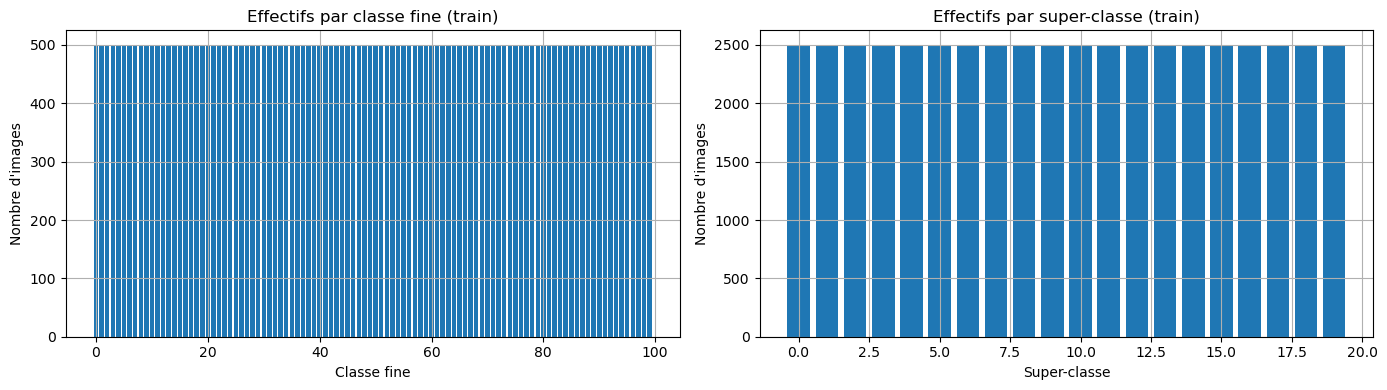

Effectif unique par classe fine (train) : [500]
Effectif unique par super-classe (train) : [2500]


In [6]:
fine_train_counts = pd.Series(y_train).value_counts().sort_index()  
# Compte le nombre d’occurrences de chaque classe fine dans l’ensemble d’entraînement, puis trie les classes par indice
fine_test_counts = pd.Series(y_test).value_counts().sort_index()  
# Compte le nombre d’occurrences de chaque classe fine dans l’ensemble de test, puis trie les classes par indice
coarse_train_counts = pd.Series(y_train_coarse).value_counts().sort_index()  
# Compte le nombre d’occurrences de chaque super-classe dans l’ensemble d’entraînement, puis trie les classes par indice
coarse_test_counts = pd.Series(y_test_coarse).value_counts().sort_index()  
# Compte le nombre d’occurrences de chaque super-classe dans l’ensemble de test, puis trie les classes par indice

balance_df = pd.DataFrame({  
    # Crée un DataFrame récapitulatif des effectifs par classe fine
    "fine_train_count": fine_train_counts,  
    # Ajoute la colonne des effectifs des classes fines dans l’ensemble d’entraînement
    "fine_test_count": fine_test_counts,  
    # Ajoute la colonne des effectifs des classes fines dans l’ensemble de test
})  # Fin de la création du DataFrame
display(balance_df.head())  
# Affiche les premières lignes du tableau récapitulatif

fig, axes = plt.subplots(1, 2, figsize=(14, 4))  
# Crée une figure avec deux sous-graphiques côte à côte

axes[0].bar(fine_train_counts.index, fine_train_counts.values)  
# Trace un diagramme en barres des effectifs par classe fine pour l’ensemble d’entraînement
axes[0].set_title("Effectifs par classe fine (train)")  
# Définit le titre du premier graphique
axes[0].set_xlabel("Classe fine")  
# Définit le label de l’axe des abscisses du premier graphique
axes[0].set_ylabel("Nombre d'images")  
# Définit le label de l’axe des ordonnées du premier graphique

axes[1].bar(coarse_train_counts.index, coarse_train_counts.values)  
# Trace un diagramme en barres des effectifs par super-classe pour l’ensemble d’entraînement
axes[1].set_title("Effectifs par super-classe (train)")  
# Définit le titre du second graphique
axes[1].set_xlabel("Super-classe")  
# Définit le label de l’axe des abscisses du second graphique
axes[1].set_ylabel("Nombre d'images")  
# Définit le label de l’axe des ordonnées du second graphique

plt.tight_layout()  
# Ajuste automatiquement les espacements pour éviter le chevauchement des éléments
plt.show()  
# Affiche la figure contenant les deux graphiques

print("Effectif unique par classe fine (train) :", fine_train_counts.unique())  
# Affiche les valeurs d’effectifs distinctes observées parmi les classes fines d’entraînement
print("Effectif unique par super-classe (train) :", coarse_train_counts.unique())  
# Affiche les valeurs d’effectifs distinctes observées parmi les super-classes d’entraînement

### Lecture

Le dataset est parfaitement équilibré :
- 500 images d'entraînement et 100 images de test par classe fine ;
- 2 500 images d'entraînement et 500 images de test par super-classe.

C'est un point fort méthodologique : les phénomènes observés ensuite ne viennent pas d'un déséquilibre de fréquence entre classes.


## 5. Statistiques descriptives globales des pixels

On calcule les statistiques élémentaires des canaux R, G, B après passage en `float32` dans [0, 1].


In [7]:
channel_stats = pd.DataFrame({  
    # Crée un DataFrame contenant des statistiques descriptives pour chaque canal de couleur
    "channel": ["R", "G", "B"],  
    # Définit les noms des trois canaux de couleur : Rouge, Vert et Bleu
    "mean": X_train_f.mean(axis=(0, 1, 2)),  
    # Calcule la moyenne des pixels pour chaque canal sur toutes les images et toutes les positions
    "std": X_train_f.std(axis=(0, 1, 2)),  
    # Calcule l’écart-type des pixels pour chaque canal
    "min": X_train_f.min(axis=(0, 1, 2)),  
    # Calcule la valeur minimale observée pour chaque canal
    "max": X_train_f.max(axis=(0, 1, 2)),  
    # Calcule la valeur maximale observée pour chaque canal
})  

display(channel_stats)  
# Affiche le tableau des statistiques des canaux

project_mean = np.array([0.5071, 0.4867, 0.4408])  
# Définit les moyennes de référence du projet pour les canaux R, G et B
project_std = np.array([0.2675, 0.2565, 0.2761])  
# Définit les écarts-types de référence du projet pour les canaux R, G et B

comparison_df = channel_stats.copy()  
# Crée une copie du DataFrame précédent pour y ajouter les valeurs de comparaison
comparison_df["project_mean"] = project_mean  
# Ajoute une colonne contenant les moyennes de référence du projet
comparison_df["project_std"] = project_std  
# Ajoute une colonne contenant les écarts-types de référence du projet
comparison_df["mean_close"] = np.isclose(comparison_df["mean"], comparison_df["project_mean"], atol=5e-3)  
# Vérifie si les moyennes calculées sont proches des moyennes de référence avec une tolérance absolue de 0,005
comparison_df["std_close"] = np.isclose(comparison_df["std"], comparison_df["project_std"], atol=5e-3)  
# Vérifie si les écarts-types calculés sont proches des écarts-types de référence avec une tolérance absolue de 0,005
display(comparison_df)  
# Affiche le tableau comparatif enrichi

,channel,mean,std,min,max
0,R,0.507075,0.267334,0.0,1.0
1,G,0.486550,0.256439,0.0,1.0
2,B,0.440919,0.276150,0.0,1.0


,channel,mean,std,min,max,project_mean,project_std,mean_close,std_close
0,R,0.507075,0.267334,0.0,1.0,0.5071,0.2675,True,True
1,G,0.486550,0.256439,0.0,1.0,0.4867,0.2565,True,True
2,B,0.440919,0.276150,0.0,1.0,0.4408,0.2761,True,True


### Lecture

Les statistiques globales montrent que :
- les trois canaux ont des moyennes proches mais pas identiques ;
- le canal bleu est globalement plus dispersé ;
- les constantes de normalisation utilisées dans le projet sont cohérentes avec les statistiques du dataset.

C'est utile pour vérifier que les manipulations de prétraitement ne reposent pas sur des hypothèses erronées.


## 6. Histogrammes globaux : non-gaussianité et limites d'interprétation

Les histogrammes sont intéressants si on a quelque chose à en dire. 

On regarde ici :

- les distributions de pixels RGB ;
- une intensité moyenne en niveaux de gris ;
- un QQ-plot ;
- quelques tests simples de normalité sur un échantillon de pixels.

> Ces histogrammes agrègent toutes les images et toutes les classes. Ils décrivent donc un mélange de distributions, pas une “loi naturelle” unique des pixels CIFAR-100.  
> Si l'on observe plusieurs bosses, cela suggère surtout un mélange de contenus visuels (objets, fonds, textures, classes), et non des modes simples à interpréter isolément.


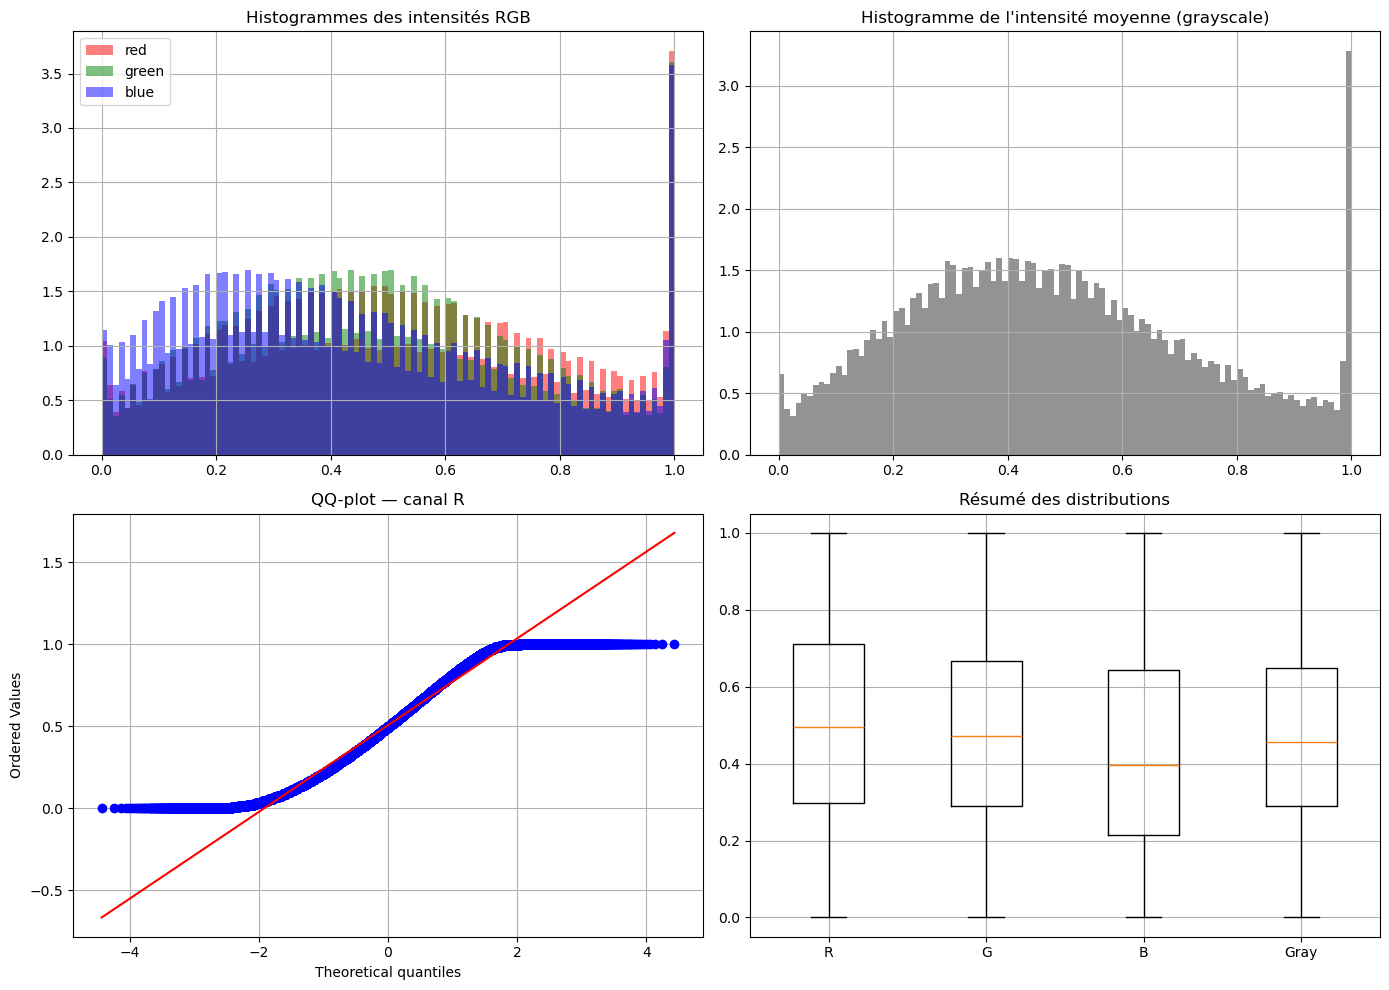

,variable,mean,std,skewness,kurtosis,shapiro_pvalue_5000pts,normaltest_pvalue
0,R,0.506974,0.267653,0.102860,-0.918487,7.916148e-29,0.0
1,G,0.486908,0.256640,0.216061,-0.750935,5.270850e-27,0.0
2,B,0.441181,0.276649,0.425264,-0.833113,2.591310e-37,0.0
3,Gray,0.478354,0.250142,0.303199,-0.664038,6.012045e-28,0.0


In [8]:
flat_pixels = X_train_f.reshape(-1, 3)  
# Transforme toutes les images d’entraînement en une longue liste de pixels RGB, chaque pixel ayant 3 composantes
pixel_idx = rng.choice(len(flat_pixels), size=min(PIXEL_SAMPLE_SIZE, len(flat_pixels)), replace=False)  
# Sélectionne aléatoirement un sous-échantillon de pixels sans remise
pixel_sample = flat_pixels[pixel_idx]  
# Extrait les pixels correspondant aux indices tirés aléatoirement
gray_sample = pixel_sample.mean(axis=1)  
# Calcule pour chaque pixel son intensité moyenne sur les 3 canaux pour obtenir une version niveau de gris

fig, axes = plt.subplots(2, 2, figsize=(14, 10))  
# Crée une figure avec une grille de 4 sous-graphiques

for i, color in enumerate(["red", "green", "blue"]):  
    # Parcourt les trois couleurs/canaux RGB avec leur indice
    axes[0, 0].hist(pixel_sample[:, i], bins=100, alpha=0.5, density=True, label=color, color=color)  
    # Trace l’histogramme normalisé des intensités du canal courant
axes[0, 0].set_title("Histogrammes des intensités RGB")  
# Définit le titre du premier sous-graphe
axes[0, 0].legend()  
# Affiche la légende des trois canaux

axes[0, 1].hist(gray_sample, bins=100, density=True, color="gray", alpha=0.85)  
# Trace l’histogramme normalisé des intensités moyennes en niveaux de gris
axes[0, 1].set_title("Histogramme de l'intensité moyenne (grayscale)")  
# Définit le titre du deuxième sous-graphe

stats.probplot(pixel_sample[:, 0], dist="norm", plot=axes[1, 0])  
# Génère un QQ-plot du canal rouge comparé à une loi normale
axes[1, 0].set_title("QQ-plot — canal R")  
# Définit le titre du troisième sous-graphe

axes[1, 1].boxplot(  
    # Trace un boxplot comparatif des distributions des canaux RGB et du grayscale
    [pixel_sample[:, 0], pixel_sample[:, 1], pixel_sample[:, 2], gray_sample],  
    # Fournit les séries de valeurs à comparer
    labels=["R", "G", "B", "Gray"],  
    # Définit les étiquettes affichées sous chaque boîte
    showfliers=False  
    # Masque les valeurs aberrantes pour rendre le graphique plus lisible
)
axes[1, 1].set_title("Résumé des distributions")  
# Définit le titre du quatrième sous-graphe

plt.tight_layout()  
# Ajuste automatiquement les espacements entre les sous-graphiques
plt.show()  
# Affiche la figure complète

def normality_report(x, name):  
    # Définit une fonction qui calcule plusieurs indicateurs descriptifs et tests de normalité
    x = np.asarray(x)  
    # Convertit l’entrée en tableau NumPy si ce n’est pas déjà le cas
    x_small = x[:5000]  
    # Conserve au plus 5000 valeurs pour le test de Shapiro afin de garder une taille raisonnable
    return {  
        # Retourne un dictionnaire contenant les statistiques calculées
        "variable": name,  
        # Nom de la variable analysée
        "mean": float(np.mean(x)),  
        # Calcule la moyenne des valeurs
        "std": float(np.std(x)),  
        # Calcule l’écart-type des valeurs
        "skewness": float(stats.skew(x)),  
        # Calcule l’asymétrie de la distribution
        "kurtosis": float(stats.kurtosis(x)),  
        # Calcule l’aplatissement de la distribution
        "shapiro_pvalue_5000pts": float(stats.shapiro(x_small).pvalue),  
        # Calcule la p-value du test de Shapiro sur l’échantillon réduit
        "normaltest_pvalue": float(stats.normaltest(x[:20000]).pvalue),  
        # Calcule la p-value du test de normalité de D’Agostino-Pearson sur jusqu’à 20000 valeurs
    }  

normality_df = pd.DataFrame([  
    # Crée un DataFrame à partir des rapports de normalité de plusieurs variables
    normality_report(pixel_sample[:, 0], "R"),  
    # Génère le rapport pour le canal rouge
    normality_report(pixel_sample[:, 1], "G"),  
    # Génère le rapport pour le canal vert
    normality_report(pixel_sample[:, 2], "B"),  
    # Génère le rapport pour le canal bleu
    normality_report(gray_sample, "Gray"),  
    # Génère le rapport pour l’intensité moyenne en niveaux de gris
])  

display(normality_df)  
# Affiche le tableau récapitulatif des statistiques et tests de normalité

### Lecture

Les intensités de pixels sont nettement non gaussiennes :
- les QQ-plots s'écartent visiblement de la droite théorique ;
- les tests de normalité donnent des p-values très faibles ;
- la distribution globale résulte d'un mélange d'objets, de fonds, de textures et de couleurs.

Certaines distributions agrégées peuvent laisser apparaître plusieurs bosses visuelles.  
Il faut toutefois les interpréter avec prudence : elles reflètent surtout le mélange des classes, des textures, des arrière-plans et des contextes visuels, plutôt qu’une structure modale simple propre à une variable isolée.

Conclusion: les histogrammes ont ici un intérêt descriptif, montrent une non-gaussianité claire et suggèrent une hétérogénéité compatible avec le mélange des classes, mais ils ne suffisent pas à eux seuls à expliquer la structure du dataset.


## 7. Quand il y a beaucoup de variables : construire des descripteurs synthétiques

On construit ici quelques descripteurs interprétables par image :

- brightness : luminosité moyenne ;
- saturation : écart moyen entre canaux max et min ;
- edge_energy : quantité de contours ;
- entropy : richesse / complexité locale ;
- statistiques couleur par canal.

L'idée est de résumer le contenu visuel avec peu de variables compréhensibles, plutôt que de commenter des milliers de pixels.


In [9]:
def compute_edge_energy(images_float):  
    # Définit une fonction qui calcule une mesure moyenne de la force des contours pour chaque image
    gray = images_float.mean(axis=3)  
    # Convertit chaque image RGB en niveau de gris en moyennant les 3 canaux de couleur
    gx = np.diff(gray, axis=2, prepend=gray[:, :, :1])  
    # Calcule les variations horizontales entre pixels voisins 
    gy = np.diff(gray, axis=1, prepend=gray[:, :1, :]) 
    # Calcule les variations verticales entre pixels voisins 
    return np.mean(np.sqrt(gx**2 + gy**2), axis=(1, 2))  
    # Calcule la norme du gradient puis en prend la moyenne sur tous les pixels de chaque image

def compute_entropy(images_float, bins=32):  
    # Définit une fonction qui calcule l’entropie des niveaux de gris de chaque image
    gray = images_float.mean(axis=3)  
    # Convertit chaque image RGB en niveau de gris en moyennant les canaux
    entropies = []  
    # Initialise une liste vide pour stocker l’entropie de chaque image
    for img in gray:  
        # Parcourt chaque image en niveau de gris
        hist, _ = np.histogram(img, bins=bins, range=(0, 1), density=False)  
        # Calcule l’histogramme des intensités de gris de l’image
        hist = hist / (hist.sum() + 1e-12)  
        # Normalise l’histogramme pour obtenir une distribution de probabilités
        entropies.append(-(hist * np.log2(hist + 1e-12)).sum())  
        # Calcule l’entropie de Shannon et l’ajoute à la liste
    return np.array(entropies)  
    # Convertit la liste des entropies en tableau NumPy et la retourne

img_channel_means = X_train_f.mean(axis=(1, 2))  
# Calcule, pour chaque image, la moyenne des pixels sur chaque canal R, G et B
img_channel_stds = X_train_f.std(axis=(1, 2))  
# Calcule, pour chaque image, l’écart-type des pixels sur chaque canal R, G et B
img_brightness = X_train_f.mean(axis=(1, 2, 3))  
# Calcule, pour chaque image, la luminosité moyenne globale sur tous les pixels et canaux
img_saturation = X_train_f.max(axis=3).mean(axis=(1, 2)) - X_train_f.min(axis=3).mean(axis=(1, 2))  
# Estime, pour chaque image, une saturation moyenne comme l’écart moyen entre canal max et canal min
img_edge = compute_edge_energy(X_train_f)  
# Calcule, pour chaque image, l’énergie moyenne des contours
img_entropy = compute_entropy(X_train_f)  
# Calcule, pour chaque image, l’entropie des niveaux de gris

df_features = pd.DataFrame({  
    # Crée un DataFrame regroupant les descripteurs calculés pour chaque image
    "mean_R": img_channel_means[:, 0],  
    # Ajoute la moyenne du canal rouge pour chaque image
    "mean_G": img_channel_means[:, 1],  
    # Ajoute la moyenne du canal vert pour chaque image
    "mean_B": img_channel_means[:, 2],  
    # Ajoute la moyenne du canal bleu pour chaque image
    "std_R": img_channel_stds[:, 0],  
    # Ajoute l’écart-type du canal rouge pour chaque image
    "std_G": img_channel_stds[:, 1],  
    # Ajoute l’écart-type du canal vert pour chaque image
    "std_B": img_channel_stds[:, 2],  
    # Ajoute l’écart-type du canal bleu pour chaque image
    "brightness": img_brightness,  
    # Ajoute la luminosité moyenne globale de chaque image
    "saturation": img_saturation,  
    # Ajoute la saturation moyenne estimée de chaque image
    "edge_energy": img_edge,  
    # Ajoute la mesure d’énergie des contours de chaque image
    "entropy": img_entropy,  
    # Ajoute l’entropie des niveaux de gris de chaque image
    "fine_label": y_train,  
    # Ajoute le label fin numérique de chaque image
    "coarse_label": y_train_coarse,  
    # Ajoute le label de super-classe numérique de chaque image
    "fine_name": [fine_label_names[i] for i in y_train],  
    # Ajoute le nom textuel de la classe fine de chaque image
    "coarse_name": [coarse_label_names[i] for i in y_train_coarse],  
    # Ajoute le nom textuel de la super-classe de chaque image
})  # Termine la création du DataFrame des caractéristiques

display(df_features.head())  
# Affiche les premières lignes du DataFrame des caractéristiques
display(df_features.drop(columns=["fine_label", "coarse_label", "fine_name", "coarse_name"]).describe().T)  
# Affiche les statistiques descriptives des variables numériques du DataFrame

,mean_R,mean_G,mean_B,std_R,std_G,std_B,brightness,saturation,edge_energy,entropy,fine_label,coarse_label,fine_name,coarse_name
0,0.591387,0.582935,0.452692,0.249921,0.283452,0.296120,0.542338,0.182824,0.116722,4.618412,19,11,cattle,large_omnivores_and_herbivores
1,0.792586,0.782449,0.750054,0.269329,0.284217,0.323592,0.775029,0.045443,0.089705,2.804586,29,15,dinosaur,reptiles
2,0.760428,0.649644,0.574441,0.193298,0.281316,0.271465,0.661504,0.188614,0.062934,4.492715,0,4,apple,fruit_and_vegetables
3,0.596841,0.626677,0.631962,0.252529,0.342741,0.349791,0.618493,0.195673,0.105213,4.526411,11,14,boy,people
4,0.440506,0.439036,0.326697,0.176419,0.171193,0.188364,0.402079,0.151157,0.091788,4.338249,1,1,aquarium_fish,fish


,count,mean,std,min,25%,50%,75%,max
mean_R,50000.0,0.507075,0.164238,0.004933,0.400732,0.495244,0.602417,0.985738
mean_G,50000.0,0.486549,0.149607,0.010911,0.390609,0.476473,0.570329,0.972373
mean_B,50000.0,0.440918,0.172797,0.004852,0.319925,0.427832,0.550125,0.978964
std_R,50000.0,0.200798,0.064608,0.003954,0.155325,0.198071,0.243821,0.451626
std_G,50000.0,0.198346,0.063543,0.011941,0.153186,0.194318,0.239678,0.459016
std_B,50000.0,0.202198,0.074275,0.004381,0.146626,0.197414,0.254255,0.464456
brightness,50000.0,0.478181,0.146988,0.027921,0.381495,0.463965,0.558700,0.966908
saturation,50000.0,0.159611,0.115763,0.000000,0.080109,0.131960,0.207676,0.945270
edge_energy,50000.0,0.084732,0.028382,0.007461,0.064826,0.083356,0.102703,0.291378
entropy,50000.0,4.067532,0.535761,0.788779,3.820656,4.187165,4.446908,4.951337


In [10]:
feature_cols = ["brightness", "saturation", "edge_energy", "entropy", "std_R", "std_G", "std_B"]  # Définit la liste des variables quantitatives à comparer entre les super-classes

kruskal_rows = []  
# Initialise une liste vide qui contiendra les résultats du test de Kruskal-Wallis pour chaque variable
for col in feature_cols:  
    # Parcourt chaque variable de la liste des caractéristiques
    groups = [grp[col].values for _, grp in df_features.groupby("coarse_name")]  
    # Regroupe les valeurs de la variable courante par super-classe
    stat, pvalue = stats.kruskal(*groups)  
    # Applique le test non paramétrique de Kruskal-Wallis pour comparer les distributions entre groupes
    kruskal_rows.append({  
        # Ajoute les résultats de la variable courante à la liste
        "feature": col,  
        # Enregistre le nom de la variable analysée
        "kruskal_H": float(stat),  
        # Enregistre la statistique H du test de Kruskal-Wallis
        "pvalue": float(pvalue),  
        # Enregistre la p-value associée au test
        "group_mean_std": float(df_features.groupby("coarse_name")[col].mean().std()),  
        # Calcule l’écart-type des moyennes de groupes pour mesurer la variabilité entre super-classes
    })

kruskal_df = pd.DataFrame(kruskal_rows).sort_values("kruskal_H", ascending=False)  
# Transforme la liste des résultats en DataFrame puis trie les variables par statistique H décroissante
display(kruskal_df)  
# Affiche le tableau des résultats du test de Kruskal-Wallis

coarse_feature_summary = (  
    # Commence la construction d’un tableau récapitulatif des moyennes par super-classe
    df_features.groupby("coarse_name")[feature_cols]  
        # Regroupe les données par nom de super-classe et sélectionne les variables d’intérêt
    .mean()  
        # Calcule la moyenne de chaque variable pour chaque super-classe
    .sort_values("brightness")  
    # Trie les super-classes selon leur luminosité moyenne
)
display(coarse_feature_summary.head(10))  
# Affiche les 10 premières lignes du tableau récapitulatif

,feature,kruskal_H,pvalue,group_mean_std
1,saturation,6561.315430,0.0,0.048266
2,edge_energy,5839.359375,0.0,0.010014
6,std_B,4972.468750,0.0,0.023130
0,brightness,3474.046875,0.0,0.040058
4,std_R,3322.000000,0.0,0.017077
3,entropy,3314.184236,0.0,0.147267
5,std_G,3052.937500,0.0,0.016135


,brightness,saturation,edge_energy,entropy,std_R,std_G,std_B
coarse_name,,,,,,,
flowers,0.412364,0.293723,0.087612,4.099201,0.238085,0.194653,0.187002
medium_mammals,0.415709,0.123662,0.090638,4.168227,0.193474,0.183594,0.177561
large_carnivores,0.427559,0.139212,0.096397,4.232932,0.196682,0.186378,0.178100
fish,0.445510,0.191882,0.071469,3.938437,0.193822,0.190314,0.189634
large_omnivores_and_herbivores,0.449295,0.136262,0.088524,4.208331,0.201339,0.200342,0.193380
trees,0.456379,0.157237,0.085458,4.247367,0.197213,0.203025,0.242843
reptiles,0.466463,0.149065,0.084243,3.900847,0.181494,0.176688,0.175787
aquatic_mammals,0.466693,0.168849,0.077778,4.017786,0.180856,0.183144,0.183238
people,0.466811,0.151153,0.090200,4.251535,0.227429,0.222138,0.222246


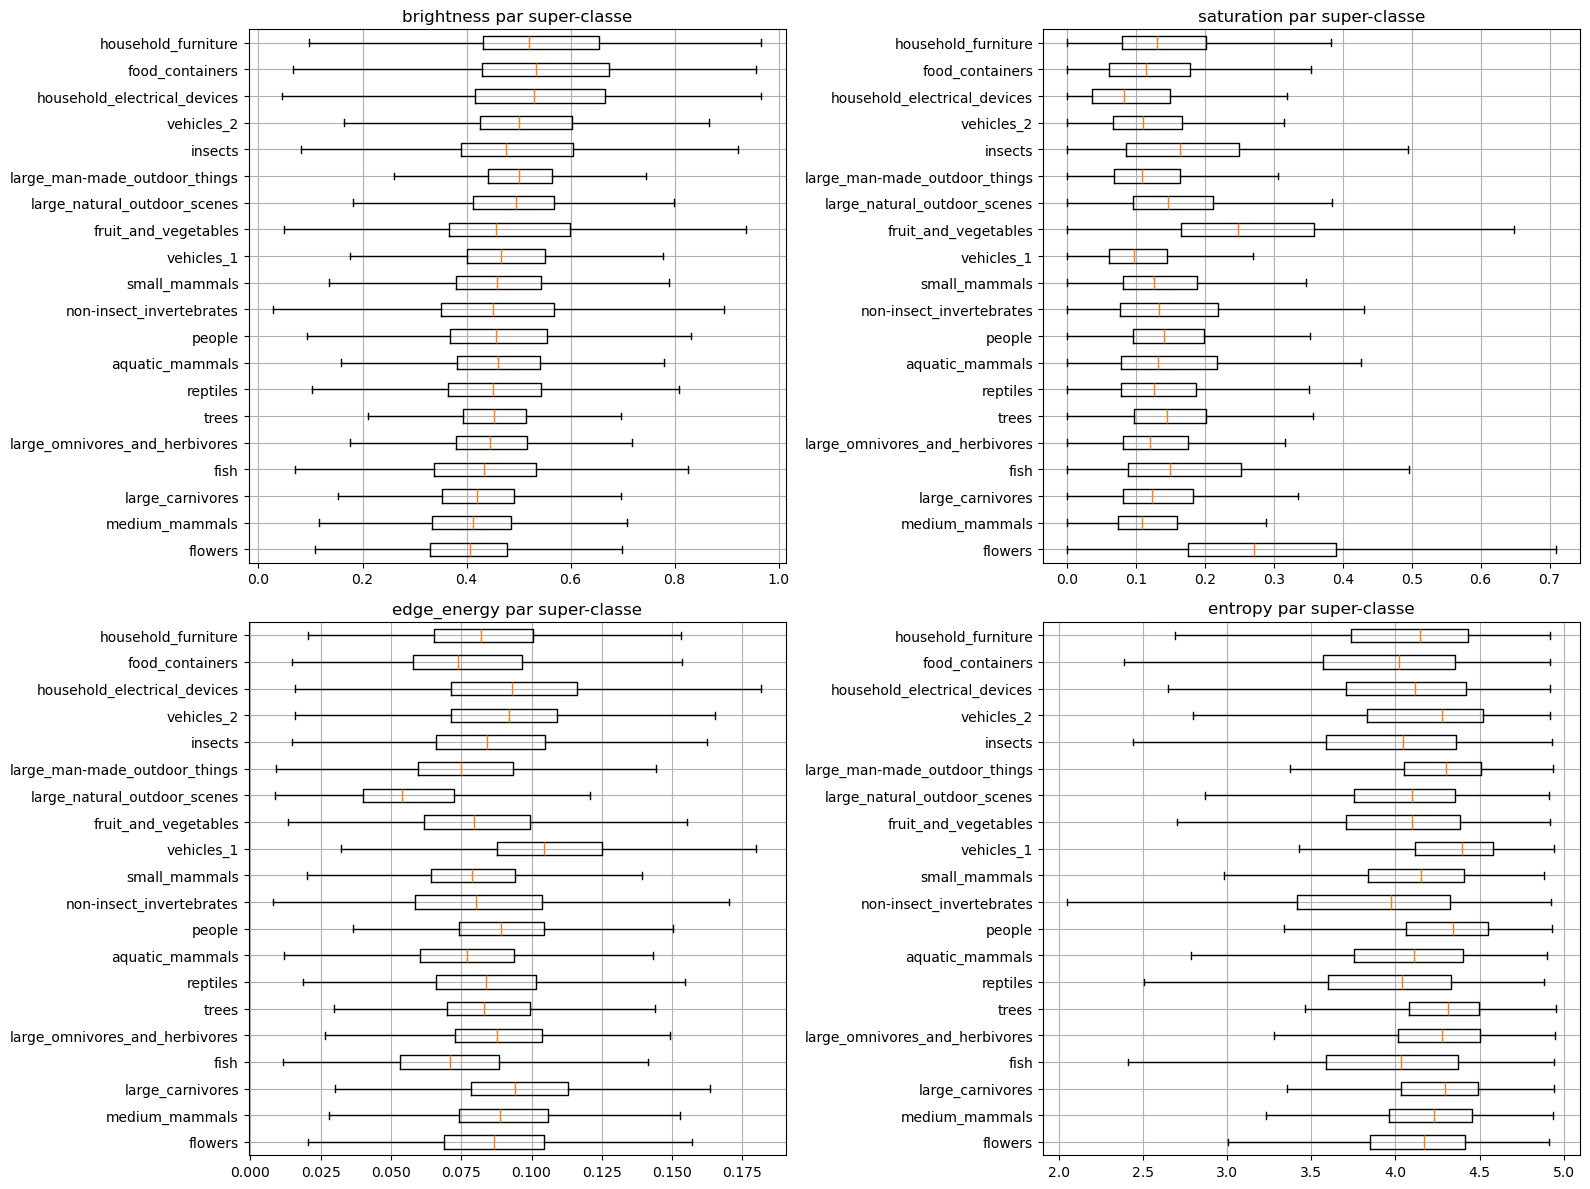

In [11]:
plot_cols = ["brightness", "saturation", "edge_energy", "entropy"]  
# Définit la liste des variables numériques à représenter dans les boxplots
fig, axes = plt.subplots(2, 2, figsize=(16, 12))  
# Crée une figure avec 4 sous-graphiques organisés en grille de 2 lignes sur 2 colonnes
axes = axes.ravel()  
# Transforme le tableau 2D des axes en tableau 1D pour faciliter la boucle

coarse_order = df_features.groupby("coarse_name")["brightness"].mean().sort_values().index.tolist()  
# Regroupe les données par super-classe, calcule la luminosité moyenne, trie ces moyennes, puis récupère l’ordre des noms de super-classes

for ax, col in zip(axes, plot_cols):  
    # Parcourt simultanément chaque axe de la figure et chaque variable à tracer
    data = [df_features.loc[df_features["coarse_name"] == c, col].values for c in coarse_order]  
    # Récupère, pour chaque super-classe, toutes les valeurs de la variable courante dans l’ordre choisi
    ax.boxplot(data, vert=False, showfliers=False)  
    # Trace un boxplot horizontal des distributions sans afficher les valeurs aberrantes
    ax.set_yticks(np.arange(1, len(coarse_order) + 1))  
    # Définit les positions des graduations sur l’axe vertical
    ax.set_yticklabels(coarse_order)  
    # Associe à chaque graduation le nom de la super-classe correspondante
    ax.set_title(f"{col} par super-classe")  
    # Définit le titre du sous-graphe avec le nom de la variable étudiée

plt.tight_layout()  
# Ajuste automatiquement les espacements pour éviter les chevauchements dans la figure
plt.show()  
# Affiche la figure

### Lecture

Cette partie répond directement à la consigne “savoir synthétiser lorsque beaucoup de variables sont en jeu”.

Les descripteurs montrent que :
- certaines super-classes diffèrent en luminosité moyenne;
- d'autres se distinguent plutôt par texture / entropie ou énergie des contours;
- les distributions par groupe se recouvrent encore, donc ces variables n'isolent pas parfaitement les classes, mais elles capturent une structure utile.

Autrement dit : on observe des tendances réelles, mais pas une séparation simple sur quelques indicateurs uniquement.


## 8. Principal Component Analysis (PCA) : variance expliquée, projection 2D/3D et réponse à “faut-il aller au-delà de 2 ou 3 axes ?”

La PCA est une méthode linéaire non supervisée.  
On l'utilise ici pour deux objectifs :

1. visualiser la structure globale ;
2. mesurer combien d'axes sont nécessaires pour résumer une part significative de la variance.

Deux précautions importantes :
- un nuage 2D peut être trompeur si l'information utile est répartie sur beaucoup d'axes ;
- il faut gérer correctement le cas où un seuil de variance n'est pas atteint dans la plage calculée.


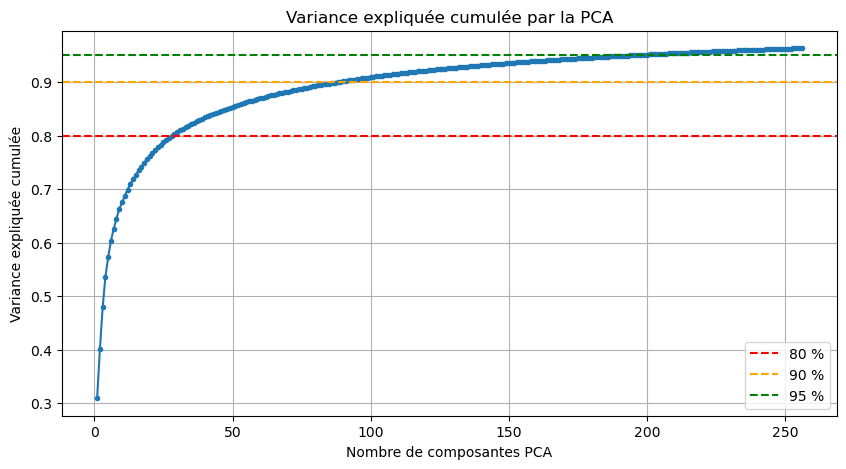

,seuil,composantes_nécessaires_dans_la_plage_testée,interprétation
0,80 %,29,atteint à k=29
1,90 %,88,atteint à k=88
2,95 %,194,atteint à k=194


In [12]:
sample_idx = rng.choice(len(X_train_f), size=min(EDA_SAMPLE_SIZE, len(X_train_f)), replace=False)  
# Sélectionne aléatoirement un sous-échantillon d’images sans remise pour l’analyse exploratoire
X_sample = X_train_f[sample_idx]  
# Extrait les images du sous-échantillon à partir des indices sélectionnés
y_sample_fine = y_train[sample_idx]  
# Extrait les labels fins correspondant aux images échantillonnées
y_sample_coarse = y_train_coarse[sample_idx]  
# Extrait les super-labels correspondant aux images échantillonnées

X_sample_flat = X_sample.reshape(len(X_sample), -1)  
# Aplati chaque image en un vecteur 1D pour obtenir une matrice de forme (nombre_d_images, nombre_de_pixels)
scaler = StandardScaler(with_mean=True, with_std=True)  
# Crée un objet de standardisation pour centrer et réduire les variables
X_sample_scaled = scaler.fit_transform(X_sample_flat)  
# Apprend les statistiques du sous-échantillon puis standardise toutes les variables

pca = PCA(n_components=PCA_MAX_COMPONENTS, svd_solver="randomized", random_state=RANDOM_STATE)  
# Crée un modèle PCA avec un nombre maximal de composantes et une SVD randomisée
X_pca = pca.fit_transform(X_sample_scaled)  
# Ajuste la PCA sur les données standardisées puis projette les données dans le nouvel espace
cumvar = np.cumsum(pca.explained_variance_ratio_)  
# Calcule la variance expliquée cumulée à partir des ratios de variance expliquée

def first_k_for_threshold(cumvar, threshold):  
    # Définit une fonction qui renvoie le premier nombre de composantes atteignant un seuil de variance expliquée
    idx = np.flatnonzero(cumvar >= threshold)  
    # Cherche les indices où la variance cumulée dépasse ou atteint le seuil demandé
    return None if len(idx) == 0 else int(idx[0] + 1)  
    # Retourne None si le seuil n’est jamais atteint, sinon retourne le rang de la première composante correspondante

k80 = first_k_for_threshold(cumvar, 0.80)  
# Détermine le nombre minimal de composantes nécessaire pour atteindre 80 % de variance expliquée
k90 = first_k_for_threshold(cumvar, 0.90)  
# Détermine le nombre minimal de composantes nécessaire pour atteindre 90 % de variance expliquée
k95 = first_k_for_threshold(cumvar, 0.95)  
# Détermine le nombre minimal de composantes nécessaire pour atteindre 95 % de variance expliquée

plt.figure(figsize=(10, 5))  
# Crée une nouvelle figure matplotlib
plt.plot(np.arange(1, len(cumvar) + 1), cumvar, marker="o", markersize=3)  
# Trace la courbe de variance expliquée cumulée en fonction du nombre de composantes
for thr, color in [(0.80, "red"), (0.90, "orange"), (0.95, "green")]:  
    # Parcourt les seuils de variance à afficher avec leur couleur associée
    plt.axhline(thr, color=color, linestyle="--", label=f"{int(thr*100)} %")  
    # Ajoute une ligne horizontale pour matérialiser chaque seuil
plt.xlabel("Nombre de composantes PCA")  
# Définit le label de l’axe des abscisses
plt.ylabel("Variance expliquée cumulée")  
# Définit le label de l’axe des ordonnées
plt.title("Variance expliquée cumulée par la PCA")  
# Définit le titre du graphique
plt.legend()  
# Affiche la légende du graphique
plt.show()  
# Affiche la figure

threshold_table = pd.DataFrame({  
    # Crée un DataFrame récapitulatif des seuils de variance expliquée
    "seuil": ["80 %", "90 %", "95 %"],  
    # Définit les seuils étudiés
    "composantes_nécessaires_dans_la_plage_testée": [k80, k90, k95],  
    # Indique le nombre de composantes nécessaires pour chaque seuil
    "interprétation": [  # Crée une colonne texte expliquant si le seuil a été atteint ou non
        "non atteint dans la plage testée" if k80 is None else f"atteint à k={k80}",  
        # Interprétation pour le seuil de 80 %
        "non atteint dans la plage testée" if k90 is None else f"atteint à k={k90}",  
        # Interprétation pour le seuil de 90 %
        "non atteint dans la plage testée" if k95 is None else f"atteint à k={k95}",  
        # Interprétation pour le seuil de 95 %
    ]
})
display(threshold_table)  
# Affiche le tableau des seuils et du nombre de composantes nécessaires

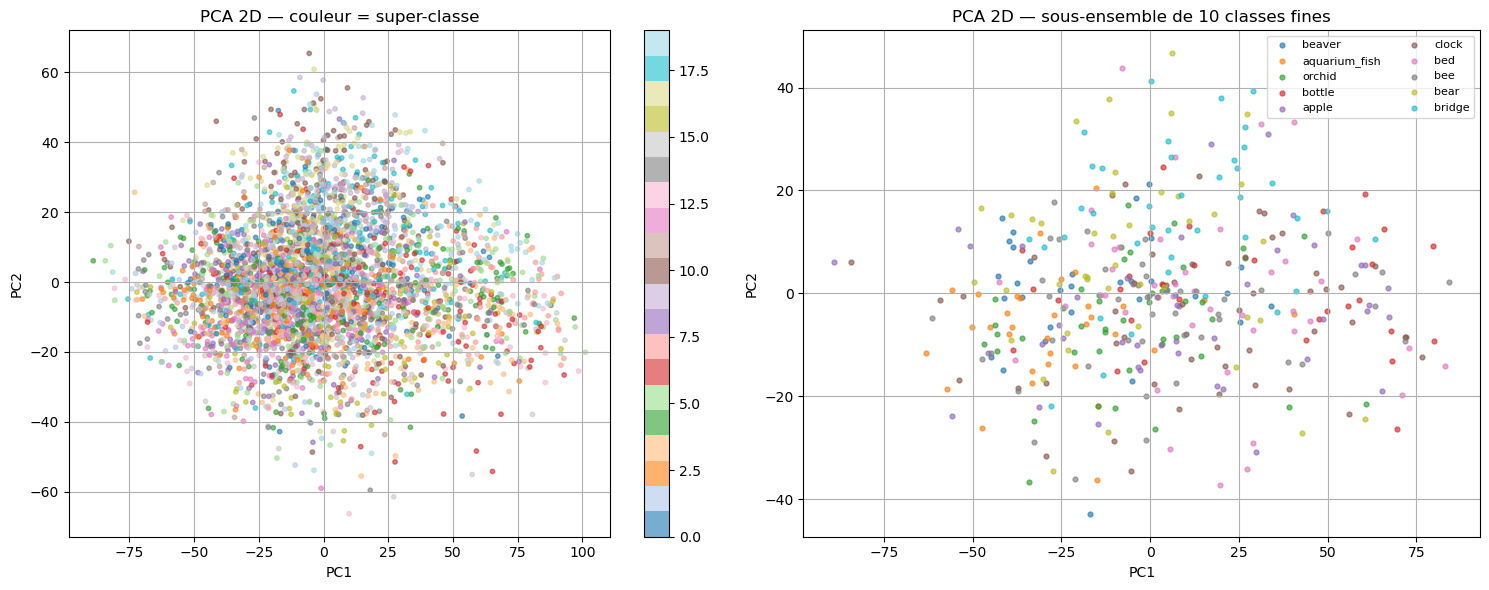

In [13]:
# Pour éviter une carte illisible à 100 couleurs, on choisit 10 classes fines réparties sur 10 super-classes.  
# Explique que l’on réduit volontairement le nombre de classes affichées pour rendre la visualisation lisible
mapping_df = (  
    # Commence la construction d’un DataFrame de correspondance entre classes fines et super-classes
    pd.DataFrame({"fine": y_train, "coarse": y_train_coarse})  
        # Crée un DataFrame avec les labels fins et les labels de super-classes du jeu d’entraînement
    .drop_duplicates()  
        # Supprime les doublons pour ne garder qu’une seule occurrence de chaque paire fine/coarse
    .sort_values(["coarse", "fine"])  
    # Trie les correspondances d’abord par super-classe puis par classe fine
)
selected_fines = mapping_df.groupby("coarse").first()["fine"].tolist()[:10]  
# Sélectionne la première classe fine de chaque super-classe, puis conserve les 10 premières
selected_fine_names = [fine_label_names[i] for i in selected_fines]  
# Convertit les indices des classes fines sélectionnées en noms de classes

mask_selected_fines = np.isin(y_sample_fine, selected_fines)  
# Crée un masque booléen indiquant quelles observations du sous-échantillon appartiennent aux classes fines retenues

fig, axes = plt.subplots(1, 2, figsize=(15, 6))  
# Crée une figure avec deux sous-graphiques côte à côte

sc0 = axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=y_sample_coarse, cmap="tab20", s=10, alpha=0.6)  
# Trace la projection PCA 2D en colorant chaque point selon sa super-classe
axes[0].set_title("PCA 2D — couleur = super-classe")  
# Définit le titre du premier graphique
axes[0].set_xlabel("PC1")  
# Définit le label de l’axe horizontal du premier graphique
axes[0].set_ylabel("PC2")  
# Définit le label de l’axe vertical du premier graphique
plt.colorbar(sc0, ax=axes[0])  
# Ajoute une barre de couleur pour interpréter les codes couleurs des super-classes

for fine in selected_fines:  
    # Parcourt les classes fines sélectionnées
    m = y_sample_fine == fine  
    # Crée un masque booléen pour isoler les observations appartenant à la classe fine courante
    axes[1].scatter(X_pca[m, 0], X_pca[m, 1], s=12, alpha=0.65, label=fine_label_names[fine])  
    # Trace les points PCA de cette classe fine avec une étiquette dans la légende
axes[1].set_title("PCA 2D — sous-ensemble de 10 classes fines")  
# Définit le titre du second graphique
axes[1].set_xlabel("PC1")  
# Définit le label de l’axe horizontal du second graphique
axes[1].set_ylabel("PC2")  
# Définit le label de l’axe vertical du second graphique
axes[1].legend(fontsize=8, ncol=2)  
# Affiche la légende des classes fines avec une petite police sur deux colonnes

plt.tight_layout()  
# Ajuste automatiquement les espacements entre les sous-graphiques
plt.show()  
# Affiche la figure

,label_set,n_dims,accuracy
0,20 super-classes,2,0.100000
1,20 super-classes,3,0.114167
2,20 super-classes,5,0.164167
3,20 super-classes,10,0.190000
4,20 super-classes,20,0.212500
5,20 super-classes,50,0.231667
6,20 super-classes,100,0.223333
7,20 super-classes,150,0.205000
8,20 super-classes,200,0.200833
9,10 classes fines,2,0.245902


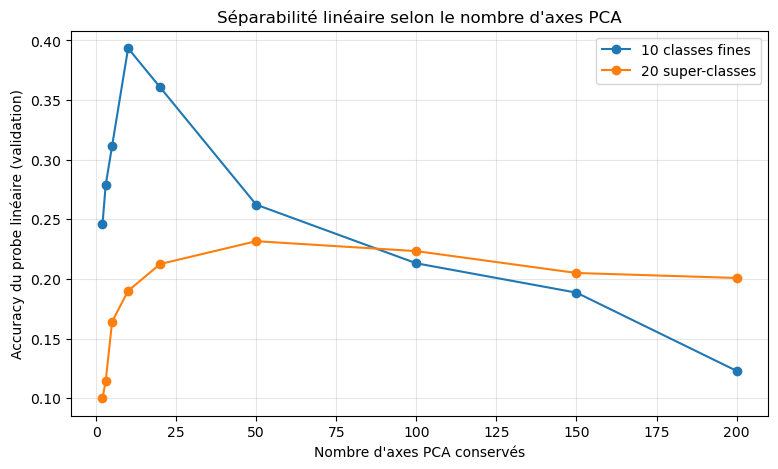

In [20]:
# Définit la liste des nombres de dimensions PCA que l’on veut tester pour le probe linéaire
dims_to_test = [2, 3, 5, 10, 20, 50, 100, 150, 200]

# Ne garde que les dimensions qui ne dépassent pas le nombre réel de composantes présentes dans X_pca
dims_to_test = [d for d in dims_to_test if d <= X_pca.shape[1]]

# Définit une fonction qui mesure la séparabilité linéaire des labels selon le nombre de dimensions utilisées
def probe_results(X_emb, y, dims_list, label_name, test_size=0.30, random_state=RANDOM_STATE):
    # Chaîne de documentation expliquant le rôle de la fonction
    """
    Évalue la séparabilité linéaire des labels dans les d premières dimensions
    d'une représentation vectorielle, pour plusieurs valeurs de d.
    """

    # Initialise une liste vide qui servira à stocker les résultats de chaque test
    rows = []

    # Sépare les données en un ensemble d'entraînement et un ensemble de validation
    X_train_probe, X_valid_probe, y_train_probe, y_valid_probe = train_test_split(
        X_emb,  # Représentation vectorielle d’entrée
        y,  # Labels associés aux observations
        test_size=test_size,  # Proportion des données réservée à la validation
        random_state=random_state,  # Fixe l’aléa pour rendre le split reproductible
        stratify=y  # Conserve la même répartition des classes dans train et validation
    )

    # Parcourt chaque nombre de dimensions PCA à tester
    for d in dims_list:
        # Crée un classificateur linéaire Ridge
        clf = RidgeClassifier(random_state=random_state)

        # Entraîne le classificateur sur les d premières dimensions de l’ensemble d’entraînement
        clf.fit(X_train_probe[:, :d], y_train_probe)

        # Prédit les labels de l’ensemble de validation à partir des d premières dimensions
        pred = clf.predict(X_valid_probe[:, :d])

        # Ajoute les résultats du test courant dans la liste rows
        rows.append({
            "label_set": label_name,  # Nom du jeu de labels évalué
            "n_dims": d,  # Nombre de dimensions utilisées pour ce test
            "accuracy": accuracy_score(y_valid_probe, pred),  # Accuracy obtenue sur l’ensemble de validation
        })

    # Convertit la liste de dictionnaires en DataFrame pandas et la retourne
    return pd.DataFrame(rows)


# Séparateur visuel pour la partie concernant les super-classes
# ------------------------------------------------------------
# Titre de section : probe sur les super-classes
# ------------------------------------------------------------

# Calcule le nombre de super-classes distinctes présentes dans y_sample_coarse
n_coarse_classes = len(np.unique(y_sample_coarse))

# Lance l’évaluation du probe linéaire sur toutes les observations avec les labels de super-classes
probe_coarse = probe_results(
    X_emb=X_pca,  # Coordonnées PCA de toutes les observations
    y=y_sample_coarse,  # Labels de super-classes
    dims_list=dims_to_test,  # Liste des dimensions PCA à tester
    label_name=f"{n_coarse_classes} super-classes"  # Nom affiché dans les résultats et le graphe
)


# Séparateur visuel pour la partie concernant les classes fines sélectionnées
# ------------------------------------------------------------
# Titre de section : probe sur le sous-ensemble de classes fines sélectionnées
# ------------------------------------------------------------

# Récupère les indices des observations appartenant aux classes fines sélectionnées
subset_idx = np.flatnonzero(mask_selected_fines)

# Extrait les coordonnées PCA des seules observations appartenant à ce sous-ensemble
X_pca_fine_subset = X_pca[subset_idx]

# Extrait les labels fins correspondants à ce sous-ensemble
y_fine_subset = y_sample_fine[subset_idx]

# Calcule le nombre de classes fines distinctes présentes dans ce sous-ensemble
n_fine_classes = len(np.unique(y_fine_subset))

# Lance l’évaluation du probe linéaire sur le sous-ensemble de classes fines sélectionnées
probe_fine = probe_results(
    X_emb=X_pca_fine_subset,  # Coordonnées PCA du sous-ensemble de classes fines
    y=y_fine_subset,  # Labels fins associés à ce sous-ensemble
    dims_list=dims_to_test,  # Liste des dimensions PCA à tester
    label_name=f"{n_fine_classes} classes fines"  # Nom affiché dans les résultats et le graphe
)


# Séparateur visuel pour la fusion des résultats
# ------------------------------------------------------------
# Titre de section : fusion des résultats
# ------------------------------------------------------------

# Concatène les résultats obtenus pour les super-classes et les classes fines dans un seul DataFrame
probe_df = pd.concat([probe_coarse, probe_fine], ignore_index=True)

# Affiche le DataFrame final contenant toutes les performances mesurées
display(probe_df)


# Séparateur visuel pour la visualisation
# ------------------------------------------------------------
# Titre de section : visualisation
# ------------------------------------------------------------

# Crée une nouvelle figure matplotlib de taille 9x5 pouces
plt.figure(figsize=(9, 5))

# Parcourt les résultats regroupés par type de labels
for label_name, grp in probe_df.groupby("label_set"):
    # Trie les lignes du groupe par nombre de dimensions croissant
    grp = grp.sort_values("n_dims")

    # Trace la courbe accuracy en fonction du nombre de dimensions pour ce groupe
    plt.plot(grp["n_dims"], grp["accuracy"], marker="o", label=label_name)

# Définit le label de l’axe horizontal
plt.xlabel("Nombre d'axes PCA conservés")

# Définit le label de l’axe vertical
plt.ylabel("Accuracy du probe linéaire (validation)")

# Définit le titre du graphique
plt.title("Séparabilité linéaire selon le nombre d'axes PCA")

# Affiche la légende pour distinguer les courbes
plt.legend()

# Ajoute une grille légère pour faciliter la lecture des valeurs
plt.grid(True, alpha=0.3)

# Affiche le graphique final
plt.show()

### Lecture

Cette section permet de répondre proprement à la consigne :

- en 2D, les classes sont partiellement structurées, mais restent largement superposées ;
- la lecture est un peu meilleure pour les super-classes que pour les classes fines ;
- les probes linéaires montrent surtout que 2 ou 3 axes ne suffisent pas ;
- la séparabilité s’améliore lorsqu’on ajoute des composantes, jusqu’à un certain point, puis peut se stabiliser ou se dégrader selon le sous-problème considéré.

Conclusion : la séparation n'est pas purement lisible en 2D ou 3D ; pour une représentation linéaire utile, il faut aller au-delà de quelques axes.

## 9. Linear Discriminant Analysis (LDA): projection supervisée

La LDA (Linear Discriminant Analysis) utilise les labels pour trouver des axes séparants.

On l'emploie à deux niveaux :

1. super-classes (20 groupes) ;
2. un sous-ensemble lisible de 10 classes fines.

Cela évite de prétendre qu'un nuage à 100 couleurs serait directement interprétable.


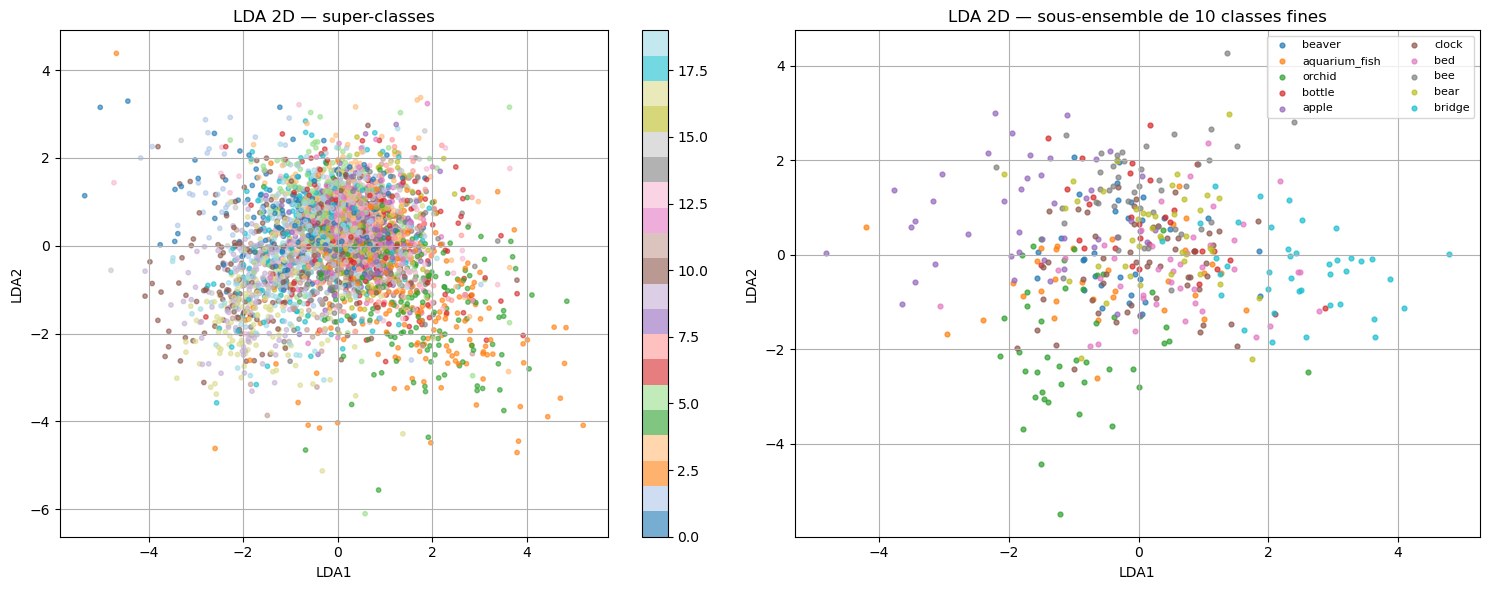

In [15]:
# LDA sur les super-classes  
pca_before_lda = PCA(n_components=min(80, X_sample_scaled.shape[1]), svd_solver="randomized", random_state=RANDOM_STATE)  
# Crée une PCA préalable pour réduire la dimension avant la LDA, avec au maximum 80 composantes
X_for_lda = pca_before_lda.fit_transform(X_sample_scaled)  
# Ajuste la PCA sur les données échantillonnées standardisées puis transforme ces données

lda_coarse = LinearDiscriminantAnalysis(n_components=2)  
# Crée un modèle LDA qui projette les données sur 2 axes discriminants
X_lda_coarse = lda_coarse.fit_transform(X_for_lda, y_sample_coarse)  
# Ajuste la LDA sur les données réduites avec les super-labels puis calcule la projection 2D

# LDA sur 10 classes fines sélectionnées  
X_fine_subset = X_for_lda[mask_selected_fines]  
# Sélectionne uniquement les observations correspondant aux classes fines retenues
y_fine_subset = y_sample_fine[mask_selected_fines]  
# Sélectionne les labels fins correspondant à ce sous-ensemble

lda_fine = LinearDiscriminantAnalysis(n_components=2)  
# Crée un second modèle LDA pour projeter ce sous-ensemble sur 2 axes discriminants
X_lda_fine = lda_fine.fit_transform(X_fine_subset, y_fine_subset)  
# Ajuste la LDA sur le sous-ensemble de classes fines puis calcule sa projection 2D

fig, axes = plt.subplots(1, 2, figsize=(15, 6))  
# Crée une figure avec deux sous-graphiques côte à côte

sc = axes[0].scatter(X_lda_coarse[:, 0], X_lda_coarse[:, 1], c=y_sample_coarse, cmap="tab20", s=10, alpha=0.6)  
# Trace la projection LDA des super-classes en colorant les points selon leur super-classe
axes[0].set_title("LDA 2D — super-classes")  
# Définit le titre du premier graphique
axes[0].set_xlabel("LDA1")  
# Définit le label de l’axe horizontal du premier graphique
axes[0].set_ylabel("LDA2")  
# Définit le label de l’axe vertical du premier graphique
plt.colorbar(sc, ax=axes[0])  
# Ajoute une barre de couleur au premier graphique pour interpréter les super-classes

for fine in selected_fines:  
    # Parcourt chacune des classes fines sélectionnées
    m = y_fine_subset == fine  
    # Crée un masque booléen pour isoler les points de la classe fine courante
    axes[1].scatter(X_lda_fine[m, 0], X_lda_fine[m, 1], s=12, alpha=0.7, label=fine_label_names[fine])  
    # Trace les points de cette classe fine dans la projection LDA avec son nom dans la légende
axes[1].set_title("LDA 2D — sous-ensemble de 10 classes fines")  
# Définit le titre du second graphique
axes[1].set_xlabel("LDA1")  
# Définit le label de l’axe horizontal du second graphique
axes[1].set_ylabel("LDA2")  
# Définit le label de l’axe vertical du second graphique
axes[1].legend(fontsize=8, ncol=2)  
# Affiche la légende des classes fines avec une petite police sur deux colonnes

plt.tight_layout()  
# Ajuste automatiquement les espacements entre les sous-graphiques
plt.show()  
# Affiche la figure

### Lecture

La LDA peut rendre certaines structures supervisées plus lisibles visuellement que la PCA, ce qui est attendu puisqu'elle utilise les labels.

Mais il faut garder du recul :

- la meilleure séparation observée ne prouve pas que le problème est “facile” ;
- elle indique surtout qu'il existe une structure linéaire supervisée partielle ;
- même avec supervision, la séparation des classes fines reste imparfaite à basse dimension.

## 10. Méthodes non linéaires : t-Distributed Stochastic Neighbor Embedding (t-SNE) et Uniform Manifold Approximation and Projection (UMAP)

Les méthodes non linéaires peuvent révéler une structure locale qui n'apparaît pas en PCA.

Mais il faut distinguer :

- structure locale / voisinages : souvent informative ;
- distances globales entre amas : souvent moins interprétables, surtout avec t-SNE.

Pour rester dans une logique d'EDA, on les utilise ici comme complément visuel à la PCA/LDA, et non comme preuve définitive de séparabilité.


In [21]:
nonlinear_idx = rng.choice(len(X_pca), size=min(NONLINEAR_SAMPLE_SIZE, len(X_pca)), replace=False)  
# Sélectionne aléatoirement un sous-échantillon d’observations pour les méthodes non linéaires
X_nl_input = X_pca[nonlinear_idx, :80]  
# Extrait les observations sélectionnées en ne conservant que les 80 premières composantes principales comme entrée
y_nl_coarse = y_sample_coarse[nonlinear_idx]  
# Extrait les super-labels correspondant aux observations sélectionnées
y_nl_fine = y_sample_fine[nonlinear_idx]  
# Extrait les labels fins correspondant aux observations sélectionnées

# masque classes fines lisibles  
# Indique que l’on crée un masque pour ne garder que les classes fines choisies pour une visualisation lisible
mask_nl_fines = np.isin(y_nl_fine, selected_fines)  
# Crée un masque booléen indiquant quelles observations appartiennent aux classes fines sélectionnées

tsne = TSNE(  
    # Crée un modèle t-SNE pour projeter les données dans un espace de dimension 2
    n_components=2,  
    # Demande une projection en 2 dimensions
    perplexity=30,  
    # Définit la perplexité, c’est-à-dire le nombre effectif de voisins pris en compte localement
    learning_rate="auto",  
    # Laisse l’algorithme choisir automatiquement un taux d’apprentissage adapté
    init="pca",  
    # Initialise la projection t-SNE à partir d’une projection PCA
    random_state=RANDOM_STATE,  
    # Fixe la graine aléatoire pour rendre les résultats reproductibles
    max_iter=1000  
    # Définit le nombre maximal d’itérations de l’algorithme
)
X_tsne = tsne.fit_transform(X_nl_input)  
# Applique t-SNE aux données d’entrée et calcule la projection 2D

umap_available = False  
# Initialise un indicateur booléen signalant que UMAP n’est pas encore disponible
try:  
    # Commence un bloc de tentative pour importer et exécuter UMAP
    import umap  
    # Importe la bibliothèque UMAP si elle est installée

    reducer = umap.UMAP(  
        # Crée un réducteur UMAP pour projeter les données en 2 dimensions
        n_components=2,  
        # Demande une projection en 2 dimensions
        n_neighbors=20,  
        # Définit le nombre de voisins pris en compte pour construire la structure locale
        min_dist=0.15,  
        # Contrôle la compacité minimale des points dans l’espace projeté
        metric="euclidean",  
        # Utilise la distance euclidienne comme mesure de similarité
        random_state=RANDOM_STATE  
        # Fixe la graine aléatoire pour rendre les résultats reproductibles
    )
    X_umap = reducer.fit_transform(X_nl_input)  
    # Applique UMAP aux données d’entrée et calcule la projection 2D
    umap_available = True  
    # Met à jour l’indicateur pour signaler que UMAP a été exécuté avec succès
except Exception as e:  
    # Intercepte toute erreur éventuelle liée à l’import ou à l’exécution de UMAP
    print("UMAP indisponible :", e)  
    # Affiche un message indiquant que UMAP n’est pas disponible avec le détail de l’erreur

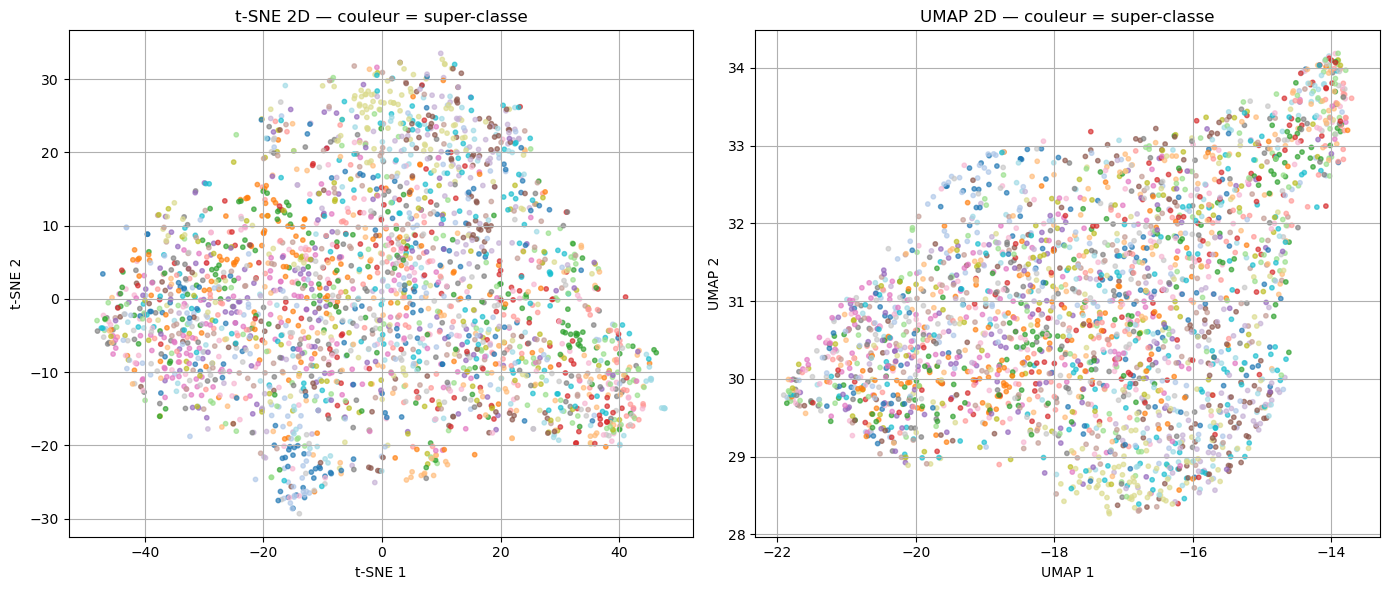

In [22]:
ncols = 2 if umap_available else 1  
# Définit le nombre de colonnes de la figure : 2 si UMAP est disponible, sinon 1 seule
fig, axes = plt.subplots(1, ncols, figsize=(7*ncols, 6))  
# Crée une figure avec une ligne et ncols sous-graphiques, avec une largeur adaptée au nombre de colonnes
if ncols == 1:  
    # Vérifie s’il n’y a qu’un seul sous-graphe
    axes = [axes]  
    # Transforme l’axe unique en liste pour uniformiser le traitement dans la suite du code

axes[0].scatter(X_tsne[:, 0], X_tsne[:, 1], c=y_nl_coarse, cmap="tab20", s=10, alpha=0.65)  
# Trace la projection t-SNE en 2D en colorant les points selon leur super-classe
axes[0].set_title("t-SNE 2D — couleur = super-classe")  
# Définit le titre du premier graphique
axes[0].set_xlabel("t-SNE 1")  
# Définit le label de l’axe horizontal du graphique t-SNE
axes[0].set_ylabel("t-SNE 2")  
# Définit le label de l’axe vertical du graphique t-SNE

if umap_available:  
    # Vérifie si une projection UMAP a bien été calculée
    axes[1].scatter(X_umap[:, 0], X_umap[:, 1], c=y_nl_coarse, cmap="tab20", s=10, alpha=0.65)  
    # Trace la projection UMAP en 2D en colorant les points selon leur super-classe
    axes[1].set_title("UMAP 2D — couleur = super-classe")  
    # Définit le titre du second graphique
    axes[1].set_xlabel("UMAP 1")  
    # Définit le label de l’axe horizontal du graphique UMAP
    axes[1].set_ylabel("UMAP 2")  
    # Définit le label de l’axe vertical du graphique UMAP

plt.tight_layout()  
# Ajuste automatiquement les espacements pour éviter les chevauchements
plt.show()  
# Affiche la figure

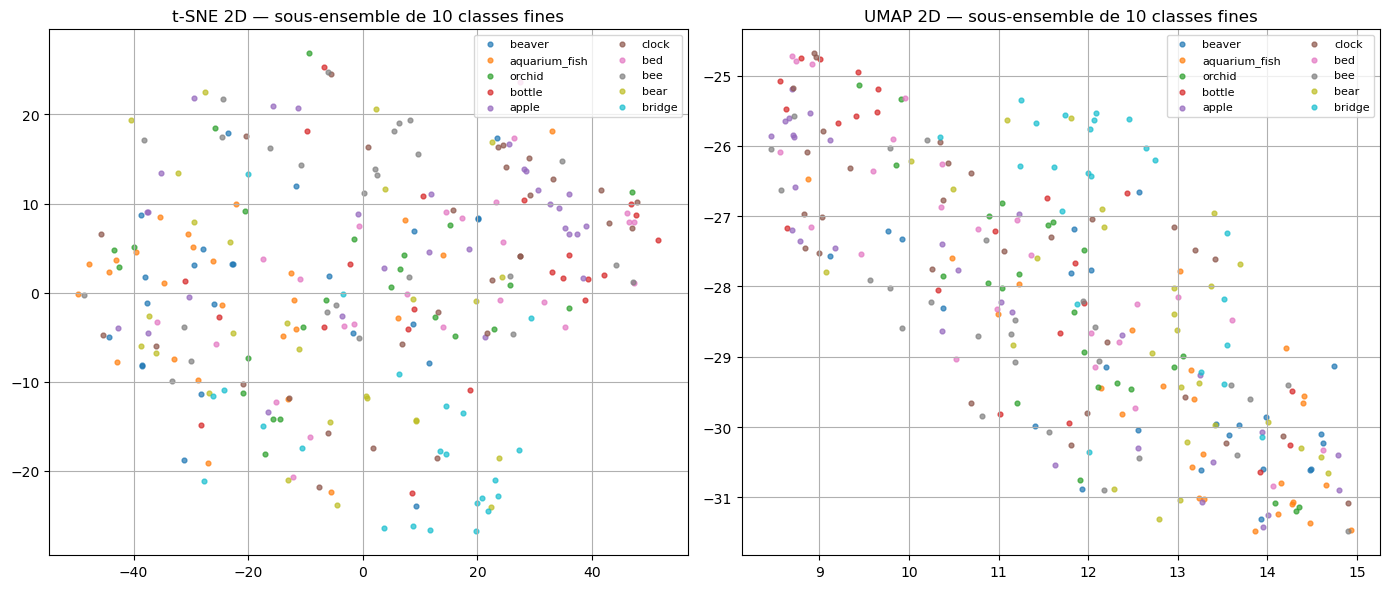

In [18]:
fig, axes = plt.subplots(1, ncols, figsize=(7*ncols, 6))  
# Crée une figure avec une ligne et ncols sous-graphiques, avec une largeur adaptée au nombre de colonnes
if ncols == 1:  
    # Vérifie s’il n’y a qu’un seul sous-graphe
    axes = [axes]  
    # Transforme l’axe unique en liste pour pouvoir le manipuler comme une collection d’axes

for fine in selected_fines:  
    # Parcourt chacune des classes fines sélectionnées pour l’affichage
    m = y_nl_fine == fine  
    # Crée un masque booléen pour repérer les points appartenant à la classe fine courante
    m = m & mask_nl_fines  
    # Combine ce masque avec le masque global des classes fines retenues
    axes[0].scatter(X_tsne[m, 0], X_tsne[m, 1], s=12, alpha=0.7, label=fine_label_names[fine])  
    # Trace sur le premier graphique les points t-SNE de la classe fine courante avec son nom en légende
axes[0].set_title("t-SNE 2D — sous-ensemble de 10 classes fines")  
# Définit le titre du graphique t-SNE
axes[0].legend(fontsize=8, ncol=2)  
# Affiche la légende des classes fines avec une petite police sur deux colonnes

if umap_available:  
    # Vérifie si la projection UMAP est disponible
    for fine in selected_fines:  
        # Parcourt chacune des classes fines sélectionnées pour l’affichage UMAP
        m = y_nl_fine == fine  
        # Crée un masque booléen pour repérer les points appartenant à la classe fine courante
        m = m & mask_nl_fines  
        # Combine ce masque avec le masque global des classes fines retenues
        axes[1].scatter(X_umap[m, 0], X_umap[m, 1], s=12, alpha=0.7, label=fine_label_names[fine])  
        # Trace sur le second graphique les points UMAP de la classe fine courante avec son nom en légende
    axes[1].set_title("UMAP 2D — sous-ensemble de 10 classes fines")  
    # Définit le titre du graphique UMAP
    axes[1].legend(fontsize=8, ncol=2)  
    # Affiche la légende des classes fines du graphique UMAP

plt.tight_layout()  
# Ajuste automatiquement les espacements entre les sous-graphiques
plt.show()  
# Affiche la figure

### Lecture

Les méthodes non linéaires peuvent faire apparaître des voisinages locaux plus lisibles visuellement que la PCA, sans pour autant améliorer clairement la séparabilité globale.

Mais une interprétation rigoureuse doit rester prudente :

- t-SNE / UMAP sont surtout utiles pour explorer une structure locale;
- une carte “plus jolie” n'implique pas automatiquement une meilleure séparabilité globale ;
- les métriques doivent être lues en complément, pas comme verdict absolu ;
- la séparation des classes fines reste partielle même si certaines sous-structures deviennent visibles.

Conclusion: ces méthodes révèlent une organisation locale partielle des données, mais ne montrent pas une séparation simple et globale des classes.

## 11. Conclusion générale

L’analyse exploratoire de CIFAR-100 met en évidence un jeu de données d’images couleur de petite taille (32×32×3), représentées par des intensités discrètes et organisées en 100 classes fines regroupées en 20 super-classes. La visualisation brute confirme d’emblée la difficulté de la tâche : faible résolution, forte variabilité intra-classe, similarités inter-classes et diversité importante des arrière-plans et des points de vue.

L’étude des distributions des pixels montre que les variables brutes présentent une structure non gaussienne, ce qui limite l’intérêt d’une lecture purement univariée et justifie le recours à des représentations plus synthétiques. Dans cette optique, les descripteurs globaux extraits des images permettent de résumer certaines propriétés visuelles pertinentes, sans toutefois suffire à discriminer clairement l’ensemble des classes.

Les méthodes de visualisation en dimension réduite confirment cette complexité. La PCA montre qu’une projection sur deux ou trois axes ne capture qu’une part limitée de l’information utile, ce qui suggère que la structure des données est répartie sur un espace de dimension plus élevée. La LDA peut améliorer la lisibilité de certaines séparations supervisées, mais ne permet pas une discrimination nette de toutes les classes fines. Enfin, les méthodes non linéaires telles que UMAP ou t-SNE mettent en évidence une organisation locale partielle des données, tout en devant être interprétées avec prudence, car elles ne garantissent pas une séparabilité globale.

En synthèse, cette EDA montre que CIFAR-100 possède une structure exploitable mais complexe, insuffisamment décrite par les pixels bruts ou par des projections linéaires de très faible dimension. Ces observations justifient l’utilisation de représentations plus riches, capables de capturer des motifs visuels locaux et des relations spatiales plus élaborées, ce qui est cohérent avec le recours ultérieur à des modèles de vision adaptés.